In [1]:
# Run this cell to set up packages for lecture.
from lec24_imports import *

# Lecture 24 – Regression and Least Squares

## DSC 10, Spring 2026

### Agenda

- The regression line in standard units.
- The regression line in original units.
- Outliers.
- Errors in prediction.

## The regression line in standard units

### Example: Predicting heights  👪 📏

Recall, in the last lecture, we aimed to use a mother's height to predict her adult son's height.

In [2]:
galton = bpd.read_csv('data/galton.csv')
male_children = galton[galton.get('gender') == 'male']
mom_son = bpd.DataFrame().assign(mom = male_children.get('mother'), 
                                 son = male_children.get('childHeight'))
mom_son

,mom,son
0,67.0,73.2
4,66.5,73.5
5,66.5,72.5
...,...,...
925,60.0,66.0
929,66.0,64.0
932,63.0,66.5


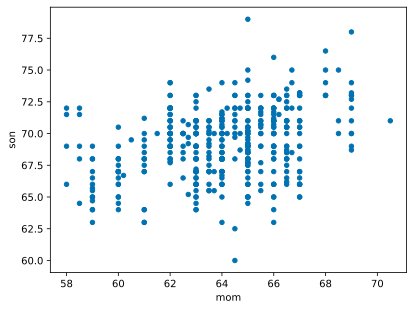

In [3]:
mom_son.plot(kind='scatter', x='mom', y='son');

### Correlation

Recall, the correlation coefficient $r$ of two variables $x$ and $y$ is defined as the 
- **average** value of the 
- **product** of $x$ and $y$
- when both are measured in **standard units**.

In [4]:
def standard_units(col):
    return (col - col.mean()) / np.std(col)

def calculate_r(df, x, y):
    '''Returns the average value of the product of x and y, 
       when both are measured in standard units.'''
    x_su = standard_units(df.get(x))
    y_su = standard_units(df.get(y))
    return (x_su * y_su).mean()

In [5]:
r_mom_son = calculate_r(mom_son, 'mom', 'son')
r_mom_son

0.3230049836849053

### The regression line

- The regression line is the line through $(0,0)$ with slope $r$, when both variables are measured in **standard units**.

<center><img src='images/regression-line.png' width=30%></center>

- We use the regression line to make predictions!

- **Example**: If a mother's height is 0.5 SDs above the average mother's height, and $r = 0.32$, our prediction is that her son's height will be $0.5 \cdot 0.32 = 0.16$ SDs above the average son's height.

- **Issue**: To use this form of the regression line, we need to know mothers' heights in standard units, but it would be more convenient to think in terms of inches.

### Concept Check ✅ – Answer at [cc.dsc10.com](http://cc.dsc10.com) 

A course has a midterm (mean 80, standard deviation 15) and a really hard final (mean 50, standard deviation 12).

If the scatter plot comparing midterm & final scores for students looks linearly associated with correlation 0.75, then what is the predicted final exam score for a student who received a 90 on the midterm?

- A. 54
- B. 56
- C. 58
- D. 60
- E. 62

## The regression line in original units

### Reflection

Each time we want to predict the height of an adult son given the height of his mother, we have to:

1. Convert the mother's height from inches to standard units.


2. Multiply by the correlation coefficient to predict the son's height in standard units.

3. Convert the son's predicted height from standard units back to inches.


This is inconvenient – wouldn't it be great if we could express the regression line itself in inches?

### From standard units to original units

When $x$ and $y$ are in standard units, the regression line is given by

<center><img src='images/regression-line.png' width=30%></center>

What is the regression line when $x$ and $y$ are in their original units (e.g. inches)?

<center><img src="images/original_standard.png" width=50%></center>

### The regression line in original units

- We can work backwards from the relationship
$$\text{predicted } y_{\text{(su)}} = r \cdot x_{\text{(su)}}$$
to find the line in original units.

$$\frac{\text{predicted } y - \text{mean of }y}{\text{SD of }y} = r \cdot \frac{x - \text{mean of } x}{\text{SD of }x}$$

- Note that $r, \text{mean of } x$, $\text{mean of } y$, $\text{SD of } x$, and $\text{SD of } y$ are constants – if you have a DataFrame with two columns, you can determine all 5 values.

- Re-arranging the above equation into the form $\text{predicted } y = mx + b$ yields the formulas:

$$\boxed{m = r \cdot \frac{\text{SD of } y}{\text{SD of }x}, \: \: b = \text{mean of } y - m \cdot \text{mean of } x}$$

- $m$ is the slope of the regression line and $b$ is the intercept.

Let's implement these formulas in code and try them out.

In [6]:
def slope(df, x, y):
    "Returns the slope of the regression line between columns x and y in df (in original units)."
    r = calculate_r(df, x, y)
    return r * np.std(df.get(y)) / np.std(df.get(x))

def intercept(df, x, y):
    "Returns the intercept of the regression line between columns x and y in df (in original units)."
    return df.get(y).mean() - slope(df, x, y) * df.get(x).mean()

Below, we compute the slope and intercept of the regression line between mothers' heights and sons' heights (in inches).

In [7]:
m_heights = slope(mom_son, 'mom', 'son')
m_heights

0.3650611602425757

In [8]:
b_heights = intercept(mom_son, 'mom', 'son')
b_heights

45.8580379719931

So, the regression line is

$$\text{predicted son's height in inches} = 0.365 \cdot \text{mother's height in inches} + 45.858$$

### Making predictions

In [9]:
def predict_son(mom):
    return m_heights * mom + b_heights

What's the predicted height of a son whose mother is 62 inches tall?

In [10]:
predict_son(62)

68.4918299070328

What if the mother is 55 inches tall? 73 inches tall?

In [11]:
predict_son(55)

65.93640178533477

In [12]:
predict_son(73)

72.50750266970113

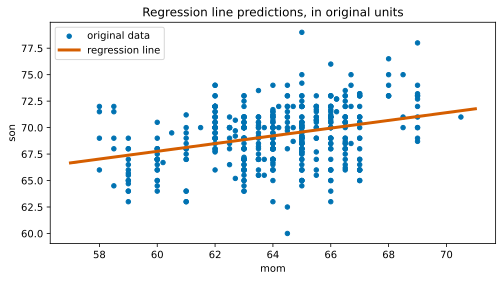

In [13]:
xs = np.arange(57, 72)
ys = predict_son(xs)
mom_son.plot(kind='scatter', x='mom', y='son', figsize=(8, 4), title='Regression line predictions, in original units', label='original data');
plt.plot(xs, ys, color=orange, lw=3, label='regression line')
plt.legend();

## Outliers

### The effect of outliers on correlation

Consider the dataset below. What is the correlation between $x$ and $y$?

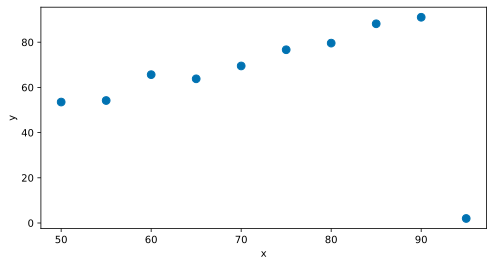

In [14]:
outlier = bpd.read_csv('data/outlier.csv')
outlier.plot(kind='scatter', x='x', y='y', s=60, figsize=(8, 4));

In [15]:
calculate_r(outlier, 'x', 'y')

-0.02793982443854457

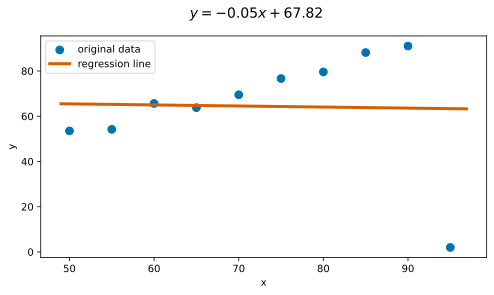

In [16]:
plot_regression_line(outlier, 'x', 'y')

### Removing the outlier

In [17]:
without_outlier = outlier[outlier.get('y') > 40]

In [18]:
calculate_r(without_outlier, 'x', 'y')

0.9851437295364016

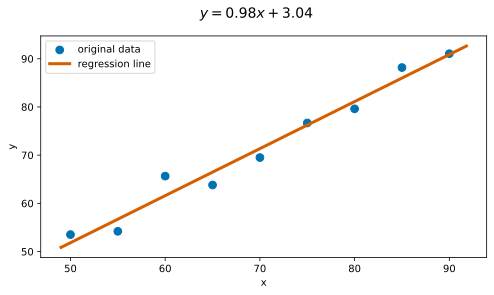

In [19]:
plot_regression_line(without_outlier, 'x', 'y')

**Takeaway**: Even a single outlier can have a massive impact on the correlation, and hence the regression line. Look for these before performing regression. **Always visualize first!**

## Errors in prediction

### Motivation

- We've presented the regression line in standard units as the line through the origin with slope $r$, given by $\text{predicted } y_{\text{(su)}} = r \cdot x_{\text{(su)}}$. Then, we used this equation to find a formula for the regression line in original units.

- In examples we've seen so far, the regression line seems to fit our data pretty well.
    - But how well? 
    - What makes the regression line good?
    - Would another line be better?

### Example: Without the outlier

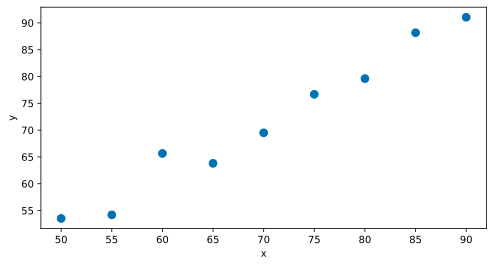

In [20]:
without_outlier.plot(kind='scatter', x='x', y='y', s=60, figsize=(8, 4));

In [21]:
m_no_outlier = slope(without_outlier, 'x', 'y')
b_no_outlier = intercept(without_outlier, 'x', 'y')

m_no_outlier, b_no_outlier

(0.975927715724588, 3.04233713529743)

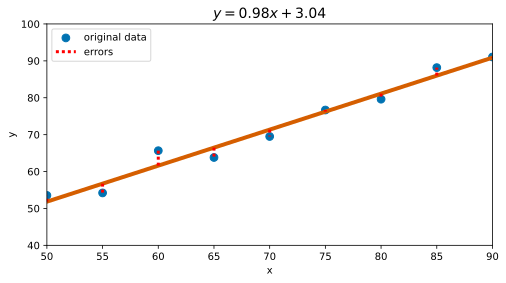

In [22]:
plot_errors(without_outlier, m_no_outlier, b_no_outlier)

We think our regression line is pretty good because most data points are pretty close to the regression line. The red lines are quite short.

### Measuring the error in prediction

$$\text{error} = \text{actual value} - \text{prediction}$$

- A good prediction line is one where the errors tend to be small.

- To measure the rough size of the errors, for a particular set of predictions:
    1. Square the errors so that they don't cancel each other out.
    2. Take the mean of the squared errors.
    3. Take the square root to fix the units.

- This is called **root mean square error** (RMSE).
    - Notice the similarities to computing the SD!

### Root mean squared error (RMSE) of the regression line's predictions

In [23]:
without_outlier

,x,y
0,50,53.53
1,55,54.21
2,60,65.65
...,...,...
6,80,79.61
7,85,88.17
8,90,91.05


First, let's compute the regression line's predictions for the entire dataset.

In [24]:
predicted_y = m_no_outlier * without_outlier.get('x') + b_no_outlier
predicted_y

array([51.84, 56.72, 61.6 , 66.48, 71.36, 76.24, 81.12, 86.  , 90.88])

To find the RMSE, we need to start by finding the errors and squaring them.

In [25]:
# Errors.
without_outlier.get('y') - predicted_y

0    1.69
1   -2.51
2    4.06
     ... 
6   -1.51
7    2.18
8    0.18
Name: y, Length: 9, dtype: float64

In [26]:
(without_outlier.get('y') - predicted_y).mean()

8.68441121484567e-15

In [27]:
# Squared errors.
(without_outlier.get('y') - predicted_y) ** 2

0     2.86
1     6.31
2    16.45
     ...  
6     2.27
7     4.74
8     0.03
Name: y, Length: 9, dtype: float64

Now, we need to find the mean of the squared errors, and take the square root of that. The result is the RMSE of the regression line's predictions.

In [28]:
# Mean squared error.
((without_outlier.get('y') - predicted_y) ** 2).mean()

4.823770221019625

In [29]:
# Root mean squared error.
np.sqrt(((without_outlier.get('y') - predicted_y) ** 2).mean())

2.196308316475541

The RMSE of the regression line's predictions is about 2.2. Is this big or small, relative to the predictions of other lines? 🤔

### Root mean squared error (RMSE) in an arbirtrary line's predictions

- We've been using the regression line to make predictions. But we could use a different line!
    - To make a prediction for `x` using an arbitrary line defined by `slope` and `intercept`, compute `x * slope + intercept`.

- For this dataset, if we choose a **different line**, we will end up with different predictions, and hence a **different RMSE**.

In [30]:
def rmse(slope, intercept):
    '''Calculates the RMSE of the line with the given slope and intercept, 
    using the 'x' and 'y' columns of without_outlier.'''

    # The true values of y.
    true = without_outlier.get('y')
    
    # The predicted values of y, from plugging the x values from the 
    # given DataFrame into the line with the given slope and intercept.
    predicted = slope * without_outlier.get('x') + intercept
    
    return np.sqrt(((true - predicted) ** 2).mean())

In [31]:
# Check that our function works on the regression line.
rmse(m_no_outlier, b_no_outlier)

2.196308316475541

Let's compute the RMSEs of several different lines on the same dataset.

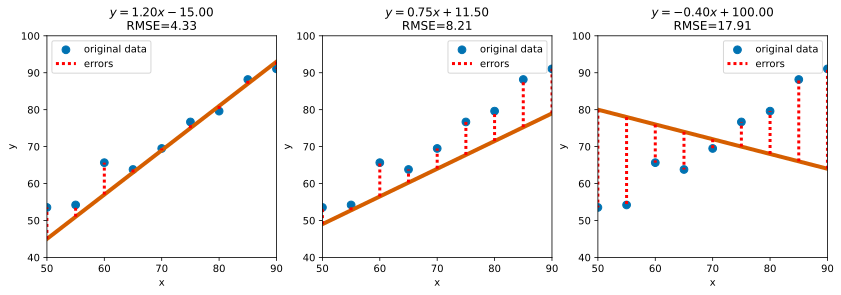

In [32]:
# Experiment by changing one of these!
lines = [(1.2, -15), (0.75, 11.5), (-0.4, 100)]

fig, ax = plt.subplots(1, 3, figsize=(14, 4))
for i, line in enumerate(lines):
    plt.subplot(1, 3, i + 1)
    m, b = line
    plot_errors(without_outlier, m, b, ax=ax[i])
    ax[i].set_title(format_equation(m, b) + f'\nRMSE={np.round(rmse(m, b), 2)}')

### Finding the "best" prediction line by minimizing RMSE

- RMSE describes how well a line fits the data. **The lower the RMSE of a line is, the better it fits the data**.

- There are infinitely many slopes and intercepts, and thus infinitely many RMSEs. How do we find which combination of slope and intercept have the lowest RMSE?

- If you take DSC 40A, you'll learn how to do this using calculus. For now, we'll use a Python function that can do it automatically – `minimize`. 

### Aside: `minimize`

- The function `minimize` takes in a function as an argument, and returns the inputs to that function that produce the smallest output. 

- For instance, we know that the minimizing input to the function $f(x) = (x - 5)^2 + 4$ is $x = 5$. `minimize` can find this, too:

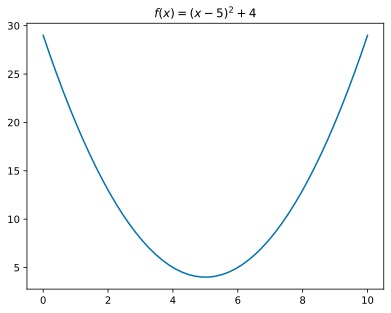

In [33]:
def f(x):
    return (x - 5) ** 2 + 4

# Plot of f(x).
x = np.linspace(0, 10)
y = f(x)
plt.plot(x, y)
plt.title(r'$f(x) = (x - 5)^2 + 4$');

In [34]:
minimize(f)

array([5.])

- The `minimize` function uses calculus and intelligent trial-and-error to find these inputs; you don't need to know how it works under the hood.

### Finding the "best" prediction line by minimizing RMSE

We'll use `minimize` on `rmse`, to find the slope and intercept of the line with the smallest RMSE.

In [35]:
smallest_rmse_line = minimize(rmse)
smallest_rmse_line

array([0.98, 3.04])

Do these numbers look familiar?

### Coincidence?

In [36]:
# The slope and intercept with the smallest RMSE, from our call to minimize.
m_smallest_rmse = smallest_rmse_line[0]
b_smallest_rmse = smallest_rmse_line[1]
m_smallest_rmse, b_smallest_rmse

(0.9759274480902261, 3.0423559111315375)

In [37]:
# The slope and intercept according to our regression line formulas.
slope(without_outlier, 'x', 'y'), intercept(without_outlier, 'x', 'y')

(0.975927715724588, 3.04233713529743)

The slopes and intercepts we got using both approaches look awfully similar... 👀

### The regression line is the best line!

- It turns out that the regression line we defined before minimizes the root mean squared error (RMSE) among all lines.

$$m = r \cdot \frac{\text{SD of } y}{\text{SD of }x}$$

$$b = \text{mean of } y - m \cdot \text{mean of } x$$

- It is the **best** line, regardless of what our data looks like!

- All equivalent names:
    - Line of “best fit”.
    - Least squares line.
    - Regression line.

- The technique of finding the slope and intercept that have the lowest RMSE is called the **method of least squares**.

### Quality of fit

- The regression line describes the "best linear fit" for a given dataset.
- The formulas for the slope and intercept work no matter what the shape of the data is.
- But the line is only meaningful if the relationship between $x$ and $y$ is roughly linear.

### Example: Non-linear data

What's the regression line for this dataset?

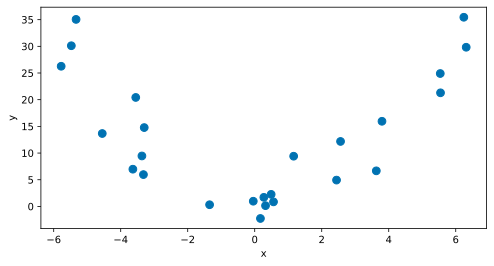

In [38]:
np.random.seed(23)
x2 = bpd.DataFrame().assign(
    x=np.arange(-6, 6.1, 0.5) + np.random.normal(size=25), 
    y=np.arange(-6, 6.1, 0.5)**2 + np.random.normal(size=25)
)
x2.plot(kind='scatter', x='x', y='y', s=60, figsize=(8, 4));

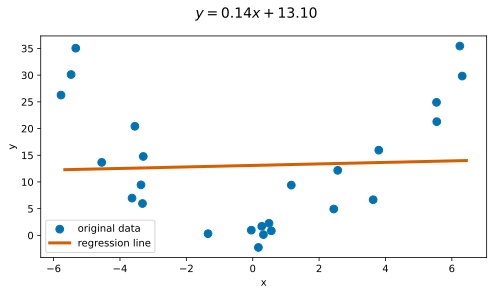

In [39]:
plot_regression_line(x2, 'x', 'y')

This line doesn't fit the data at all!

### Residuals

- Any set of predictions has _errors_.

$$\text{error} = \text{actual } y - \text{predicted } y$$


- When using the regression line to make predictions, the errors are called **residuals**.
     
$$\text{residual} = \text{actual } y - \text{predicted } y \text{ by regression line}$$

- There is one residual corresponding to each data point $(x, y)$ in the dataset.

- You'll explore residuals further in Lab 7, and we'll discuss them again in the next lecture.

### Summary, next time

### Summary

- The regression line in original units is $\text{predicted } y = mx + b$, where

$$m = r \cdot \frac{\text{SD of } y}{\text{SD of }x}$$

$$b = \text{mean of } y - m \cdot \text{mean of } x$$
- This line is very sensitive to outliers.
- This line has the lowest root mean squared error (RMSE) of all possible lines.
    - It is the "line of best fit".

### Next time

- As we saw, the regression line is the best *line* to fit the data, but not all data is linear. 
- How do we determine whether fitting a line even makes sense for our dataset?
- When we use regression, we're making predictions based on data in a sample. What if we had a different sample?
